1. **Prove** that FD = 1 for a line, FD = 2 for a surface, FD = 3 for random data, and FD > expected when noise is added
2. **Find** the approximate formulas for FD that avoid the exploding nested summation
3. **Test** those formulas and find their limits (stress tests)
4. **Understand and compute** MIC statistics
5. **Compute** the full n×m dependency matrix
6. **Test** whether summing all MIC values is a good summary, and compare with per-input ranking
7. **Detailed parametric study** of Levina-Bickel and Two-NN at GNN-relevant dimensions (N, k, D_AMBIENT sweeps)
8. **Joint FD approach** — generalisation to n inputs and m outputs
9. **Detecting useless inputs** — does FD stay flat when a noise variable is added?
10. **Template for real training data** — ready-to-use cells for when the actual GNN dataset is available

In [12]:
# SETUP

## Importation

import subprocess
subprocess.run(["pip", "install", "scikit-dimension", "-q"])

import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

## Definition of functions

# --- FD method 1: Levina-Bickel ---
def levina_bickel(data, k=10):
    
    nn = NearestNeighbors(n_neighbors=k+1)  #détermination des nearest neighbors 
    nn.fit(data)
    distances, _ = nn.kneighbors(data)
    distances = distances[:, 1:]
    #print(distances)
    r_k = distances[:, -1]  #take the neighbor the most far away
    
    estimates = []
    
    for i in range(len(data)):
        if r_k[i] > 0:
            ratio_logs = np.log(r_k[i] / distances[i, :-1])
            if np.all(ratio_logs > 0):
                estimates.append((k - 1) / np.sum(ratio_logs))
    
    return np.mean(estimates)

# --- FD method 2: Two-NN ---


def two_nn_Pareto(data):  #useless until now
    nn = NearestNeighbors(n_neighbors=3)   # we put 3 and not 2 because the point itself will be countde as a nearest neighbor
    nn.fit(data)
    distances, _ = nn.kneighbors(data)
    distances = distances[:, 1:]
    r1 = distances[:, 0]
    r2 = distances[:, 1]
    valid = r1 > 0
    mu = r2[valid] / r1[valid]
    return len(mu) / np.sum(np.log(mu))

def two_nn(data):   #data is a table with the data to analyse
    nn = NearestNeighbors(n_neighbors=3)  
                                            #we call an object from the class nearest neighbor
                                             # we put 3 and not 2 because the point itself will be counted as a nearest neighbor
    
    nn.fit(data)  #organise les données pour qu'elle soit exploitable et qu'on puisse trouver facilement tous les voisins
    distances, _ = nn.kneighbors(data)
    distances = distances[:, 1:]
    r1 = distances[:, 0]
    r2 = distances[:, 1]
    valid = r1 > 0
    mu = r2[valid] / r1[valid]
    mu_sorted=np.sort(mu)
    N=len(mu_sorted)
    F_emp=np.arange(1,N+1)/N
    mu_sorted=mu_sorted[:-1]
    F_emp=F_emp[:-1]
    x=np.log(mu_sorted)
    y=-np.log(1-F_emp)
    d=np.sum(x*y)/np.sum(x**2)
    return d

# --- FD method 3: Grassberger-Procaccia (subsampled) ---
def grassberger_procaccia(data, n_pairs=50000, n_epsilons=20):
    N = len(data)
    idx1 = np.random.randint(0, N, n_pairs)
    idx2 = np.random.randint(0, N, n_pairs)
    valid = idx1 != idx2
    idx1, idx2 = idx1[valid], idx2[valid]
    diffs     = data[idx1] - data[idx2]
    
    distances = np.sqrt(np.sum(diffs**2, axis=1))  #Computation of all the distances
    distances = distances[distances > 0]  #we exclude the distances equal to zero
    
    eps_min  = np.percentile(distances, 5)  #before that the distances can be instable (Claude)
    eps_max  = np.percentile(distances, 50)  #after that the data will not be representative
    epsilons = np.logspace(np.log10(eps_min), np.log10(eps_max), n_epsilons)
    
    C     = np.array([np.mean(distances < eps) for eps in epsilons])
    valid_C = C > 0
    slope, _ = np.polyfit(np.log(epsilons[valid_C]), np.log(C[valid_C]), 1)  #we estimate the slope
    
    return slope

# --- FD method 4: Box-counting ---
def box_counting(data, n_scales=10):
    data_norm = (data - data.min(axis=0)) / (data.max(axis=0) - data.min(axis=0) + 1e-10)
    scales    = np.logspace(-0.3, -1.5, n_scales)
    n_boxes   = []
    valid_eps = []
    for eps in scales:
        box_ids      = np.floor(data_norm / eps).astype(int)
        unique_boxes = len(set(map(tuple, box_ids)))
        if unique_boxes > 1:
            n_boxes.append(unique_boxes)
            valid_eps.append(eps)
    if len(valid_eps) < 3:
        return np.nan
    slope, _ = np.polyfit(np.log(1.0 / np.array(valid_eps)), np.log(np.array(n_boxes)), 1)
    return slope

# --- FD method 5: Takens ---
def takens(data, k=20):
    nn = NearestNeighbors(n_neighbors=k+1)
    nn.fit(data)
    distances, _ = nn.kneighbors(data)
    distances = distances[:, 1:]
    r_k = distances[:, -1]
    estimates = []
    for i in range(len(data)):
        if r_k[i] > 0:
            log_ratios = np.log(r_k[i] / distances[i, :-1])
            valid = log_ratios > 0
            if valid.sum() > 0:
                estimates.append(k / np.sum(log_ratios[valid]))
    return np.mean(estimates) if estimates else np.nan

# --- Pseudo-MIC score ---
def compute_pseudo_mic(x, y):
    """kNN mutual information + Linfoot transformation -> bounded in [0, 1]."""
    mi = mutual_info_regression(x.reshape(-1, 1), y, random_state=42)[0]
    return 1 - np.exp(-2 * mi)

# --- Timer helper ---
def run_and_time(method, data, **kwargs):
    start   = time.time()
    result  = method(data, **kwargs)
    elapsed = time.time() - start
    return result, elapsed

# --- All methods dict ---
all_methods = {
    'Levina-Bickel' : lambda d: levina_bickel(d, k=10),
    'Two-NN'        : two_nn,
    'Grassberger-P' : grassberger_procaccia,
    'Box-counting'  : box_counting,
    'Takens'        : lambda d: takens(d, k=20),
}
method_names = list(all_methods.keys())
colors       = ['steelblue', 'coral', 'green', 'purple', 'orange']

print('Setup complete — all functions loaded.')

Setup complete — all functions loaded.


---
## Point 1 — Prove that FD works

- Completely random data (x, y, z independent) → FD = 3
- Smooth surface z = sin(x·y) → FD = 2
- Straight line → FD = 1
- Line + noise → FD slightly > 1
- Surface + noise → FD slightly > 2

We use **Two-NN** as the primary method (fastest and most accurate in our tests).

In [11]:
### POINT 1 — Proof that FD captures geometric structure using Two_NN method

N = 2000

proof_cases    = {}
proof_expected = {}

# Case 1: straight line (FD should be 1)
t = np.random.uniform(0, 10, N)
proof_cases['Straight line']      = np.column_stack([t, 2*t + 1])
proof_expected['Straight line']   = 1.0

# Case 2: line with noise (FD should be slightly > 1)
t = np.random.uniform(0, 10, N)
proof_cases['Noisy line']         = np.column_stack([t, 2*t + 1 + 0.5*np.random.normal(0,1,N)])
proof_expected['Noisy line']      = 1.2  # approximate

# Case 3: smooth surface (FD should be 2)
x = np.random.uniform(0, 5, N)
y = np.random.uniform(0, 5, N)
proof_cases['Smooth surface']     = np.column_stack([x, y, np.sin(x*y)])
proof_expected['Smooth surface']  = 2.0

# Case 4: noisy surface (FD should be slightly > 2)
x = np.random.uniform(0, 5, N)
y = np.random.uniform(0, 5, N)
proof_cases['Noisy surface']      = np.column_stack([x, y, np.sin(x*y) + 0.3*np.random.normal(0,1,N)])
proof_expected['Noisy surface']   = 2.3  # approximate

# Case 5: completely random (FD should be 3)
proof_cases['Random (x,y,z)']     = np.random.uniform(0, 5, (N, 3))
proof_expected['Random (x,y,z)']  = 3.0

print("Computing FD with Two-NN on all proof cases...\n")
print(f"{'Case':<20} {'Expected':>10} {'Measured':>10} {'Difference':>12} {'Conclusion'}")
print("-" * 72)

for name, data in proof_cases.items():
    fd, _  = run_and_time(two_nn, data)
    diff   = fd - proof_expected[name]
    print(f"{name:<20} {proof_expected[name]:>10.1f} {fd:>10.3f} {diff:>+12.3f}")


Computing FD with Two-NN on all proof cases...

Case                   Expected   Measured   Difference Conclusion
------------------------------------------------------------------------
Straight line               1.0      1.017       +0.017
Noisy line                  1.2      2.067       +0.867
Smooth surface              2.0      2.106       +0.106
Noisy surface               2.3      2.939       +0.639
Random (x,y,z)              3.0      2.936       -0.064


---
### Same proof with Levina-Bickel and Grassberger-Procaccia

To cross-validate, we run the same simple geometries through Levina-Bickel and the subsampled Grassberger-Procaccia estimator.

In [9]:
## POINT 1 bis — Simple geometries with LB + GP


N = 2000

t      = np.random.uniform(0, 10, N)
line   = np.column_stack([t, 2*t + 1])

x, y   = np.random.uniform(0, 5, N), np.random.uniform(0, 5, N)
surface = np.column_stack([x, y, np.sin(x * y)])

x, y   = np.random.uniform(0, 5, N), np.random.uniform(0, 5, N)
noisy  = np.column_stack([x, y, np.sin(x * y) + 0.3 * np.random.normal(0, 1, N)])

random_data = np.random.uniform(0, 5, (N, 3))

cases_1b = {'Line':    (line,        1.0),
            'Surface': (surface,     2.0),
            'Noisy':   (noisy,       2.3),
            'Random':  (random_data, 3.0)}

print(f"{'Case':<12} {'Expected':>9} {'Levina-Bickel':>15} {'Grassberger-P':>15}")
print('-' * 55)

lb_vals, gp_vals, exp_vals, names_1b = [], [], [], []

for name, (data, expected) in cases_1b.items():
    lb = levina_bickel(data, k=10)
    gp = grassberger_procaccia(data)
    print(f"{name:<12} {expected:>9.1f} {lb:>15.3f} {gp:>15.3f}")
    lb_vals.append(lb)
    gp_vals.append(gp)
    exp_vals.append(expected)
    names_1b.append(name)

Case          Expected   Levina-Bickel   Grassberger-P
-------------------------------------------------------
Line               1.0           1.128           0.941
Surface            2.0           2.310           2.166
Noisy              2.3           3.003           2.227
Random             3.0           3.215           2.377


---
## Point 2 — Approximate formulas for FD

The exact Grassberger-Procaccia formula requires computing all N² pairwise distances, impossible for large datasets.
We compare 5 approximate methods and measure their accuracy and speed.

In [17]:
# =============================================================================
# POINT 2 — Compare all 5 approximate FD methods
# =============================================================================

N = 2000

cases    = {}
expected = {}

t = np.random.uniform(0, 10, N)
cases['Line (1D)']              = np.column_stack([t, 2*t + 1])
expected['Line (1D)']           = 1.0

x = np.random.uniform(0, 5, N)
y = np.random.uniform(0, 5, N)
cases['Smooth surface (2D)']    = np.column_stack([x, y, np.sin(x*y)])
expected['Smooth surface (2D)'] = 2.0

x = np.random.uniform(0, 5, N)
y = np.random.uniform(0, 5, N)
cases['Noisy surface (~2.3)']   = np.column_stack([x, y, np.sin(x*y) + 0.3*np.random.normal(0,1,N)])
expected['Noisy surface (~2.3)'] = 2.3

cases['Random 3D']              = np.random.uniform(0, 5, (N, 3))
expected['Random 3D']           = 3.0

t = np.random.uniform(0, 2*np.pi, N)
cases['Curved line 3D (1D)']    = np.column_stack([np.cos(t), np.sin(t), t])
expected['Curved line 3D (1D)'] = 1.0

case_names = list(cases.keys())
results    = {m: {} for m in all_methods}
times      = {m: {} for m in all_methods}
errors     = {m: {} for m in all_methods}

## Computation of all the methods

for name, data in cases.items():
    for mname, mfunc in all_methods.items():
        fd, t = run_and_time(mfunc, data)
        results[mname][name] = fd
        times[mname][name]   = t
        errors[mname][name]  = abs(fd - expected[name]) if not np.isnan(fd) else np.nan

# Summary table
print("=" * 105)
print("RESULTS — Measured FD vs Expected FD")
print("=" * 105)
header = f"{'Case':<24} {'Exp':>5}"
for m in method_names:
    header += f"  {m[:12]:>12} {'Err':>5}"
print(header)
print("-" * 105)
for name in case_names:
    row = f"{name:<24} {expected[name]:>5.1f}"
    for m in method_names:
        row += f"  {results[m][name]:>12.3f} {errors[m][name]:>5.3f}"
    print(row)

print()
print("=" * 70)
print("RANKING — Mean Absolute Error per method (lower = better)")
print("=" * 70)
mae_list = []
for m in method_names:
    errs = [errors[m][n] for n in case_names if not np.isnan(errors[m][n])]
    mae  = np.mean(errs)
    mt   = np.mean(list(times[m].values()))
    mae_list.append((m, mae, mt))
for rank, (m, mae, mt) in enumerate(sorted(mae_list, key=lambda x: x[1])):
    print(f"  #{rank+1}  {m:<20}  MAE = {mae:.3f}   time = {mt:.4f}s")


RESULTS — Measured FD vs Expected FD
Case                       Exp  Levina-Bicke   Err        Two-NN   Err  Grassberger-   Err  Box-counting   Err        Takens   Err
---------------------------------------------------------------------------------------------------------
Line (1D)                  1.0         1.138 0.138         1.016 0.016         0.952 0.048         0.981 0.019         1.119 0.119
Smooth surface (2D)        2.0         2.321 0.321         2.042 0.042         2.193 0.193         1.892 0.108         2.353 0.353
Noisy surface (~2.3)       2.3         2.991 0.691         2.712 0.412         2.240 0.060         1.954 0.346         2.874 0.574
Random 3D                  3.0         3.236 0.236         2.677 0.323         2.396 0.604         2.027 0.973         3.168 0.168
Curved line 3D (1D)        1.0         1.117 0.117         0.986 0.014         0.973 0.027         1.121 0.121         1.106 0.106

RANKING — Mean Absolute Error per method (lower = better)
  #1  Two-NN

---
## Point 3 — Stress tests: until what limit are the formulas accurate?

Tagarielli explicitly asks: *"let's find the approximate formulas and put them to the test, to see until what limit they are accurate."*

We test two things:
- **Stress test A**: what happens when we reduce the number of points N?
- **Stress test B**: what happens when the ambient dimension increases?

Stress test A — varying N (smooth surface, expected FD = 2)

  N =   100 done
  N =   200 done
  N =   500 done
  N =  1000 done
  N =  2000 done
  N =  5000 done


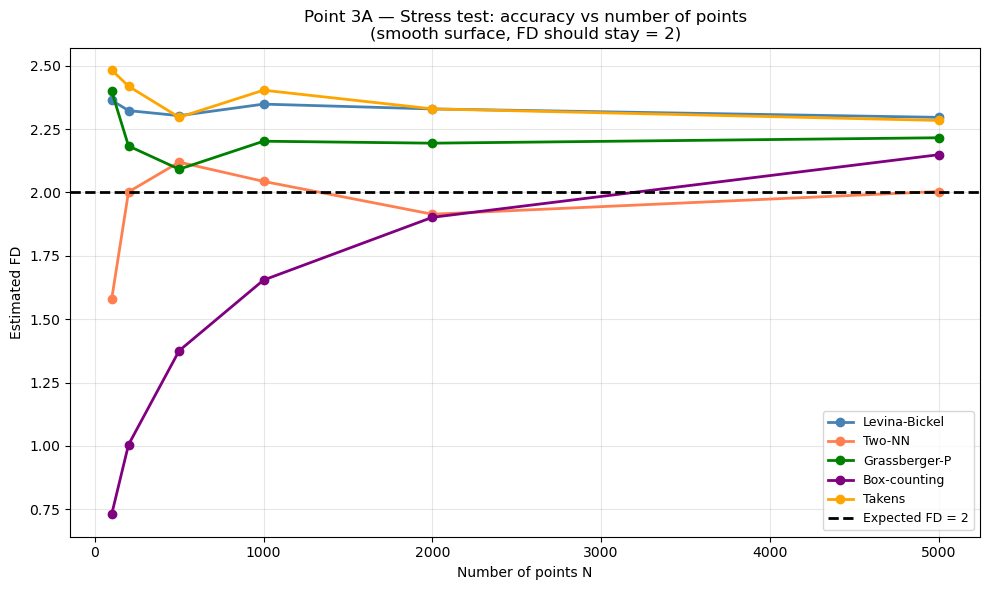


-> Look at which methods converge to FD=2 quickly (good) vs need many points (bad)
-> Below a certain N, all methods become unreliable — that is the limit Tagarielli asks about


In [5]:
# =============================================================================
# POINT 3A — Stress test: accuracy vs number of points N
# Reference: smooth surface, expected FD = 2
# =============================================================================

N_values       = [100, 200, 500, 1000, 2000, 5000]
stress_N       = {m: [] for m in all_methods}

print("Stress test A — varying N (smooth surface, expected FD = 2)\n")
for N_test in N_values:
    x = np.random.uniform(0, 5, N_test)
    y = np.random.uniform(0, 5, N_test)
    z = np.sin(x * y)
    data_test = np.column_stack([x, y, z])
    for mname, mfunc in all_methods.items():
        fd, _ = run_and_time(mfunc, data_test)
        stress_N[mname].append(fd)
    print(f"  N = {N_test:5d} done")

fig, ax = plt.subplots(figsize=(10, 6))
for i, m in enumerate(method_names):
    ax.plot(N_values, stress_N[m], marker='o', color=colors[i], label=m, linewidth=2)
ax.axhline(y=2.0, color='black', linestyle='--', linewidth=2, label='Expected FD = 2')
ax.set_xlabel('Number of points N')
ax.set_ylabel('Estimated FD')
ax.set_title('Point 3A — Stress test: accuracy vs number of points\n'
             '(smooth surface, FD should stay = 2)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n-> Look at which methods converge to FD=2 quickly (good) vs need many points (bad)")
print("-> Below a certain N, all methods become unreliable — that is the limit Tagarielli asks about")

Stress test B — varying ambient dimension (2D surface, expected FD = 2)

  d =   3 done
  d =   5 done
  d =   8 done
  d =  10 done
  d =  15 done
  d =  20 done


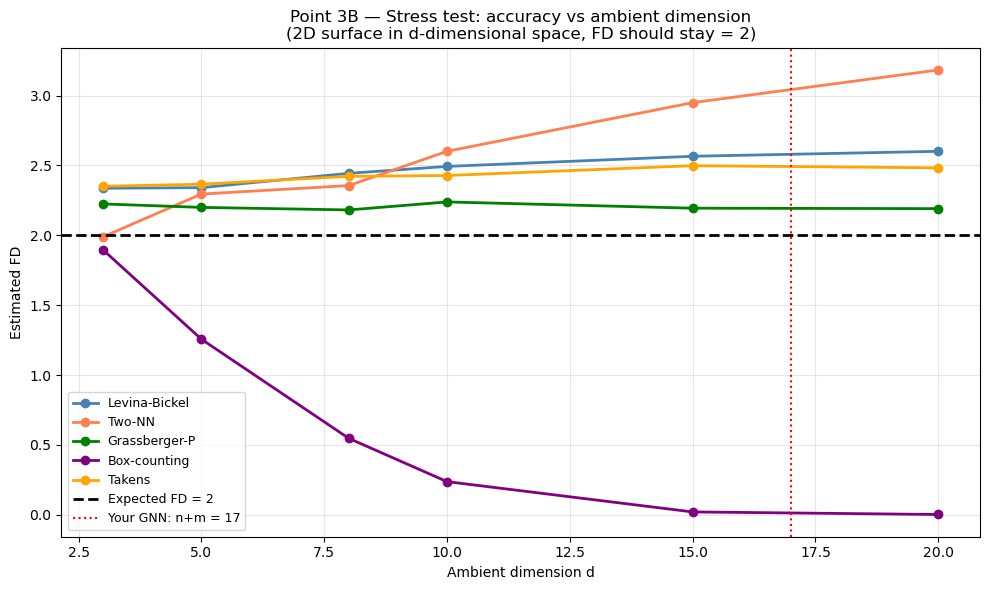


-> The red dotted line shows your real problem dimension (n+m = 17)
-> Methods that deviate from FD=2 before d=17 are unreliable for your dataset


In [6]:
# =============================================================================
# POINT 3B — Stress test: accuracy vs ambient dimension
# A 2D surface embedded in a space of increasing dimension d
# Expected FD stays = 2 regardless of d
# =============================================================================

N          = 2000
dim_values = [3, 5, 8, 10, 15, 20]
stress_dim = {m: [] for m in all_methods}

print("Stress test B — varying ambient dimension (2D surface, expected FD = 2)\n")
for d in dim_values:
    x = np.random.uniform(0, 5, N)
    y = np.random.uniform(0, 5, N)
    z = np.sin(x * y)
    extra     = np.random.normal(0, 0.01, (N, d - 3))
    data_test = np.column_stack([x, y, z, extra])
    for mname, mfunc in all_methods.items():
        fd, _ = run_and_time(mfunc, data_test)
        stress_dim[mname].append(fd)
    print(f"  d = {d:3d} done")

fig, ax = plt.subplots(figsize=(10, 6))
for i, m in enumerate(method_names):
    ax.plot(dim_values, stress_dim[m], marker='o', color=colors[i], label=m, linewidth=2)
ax.axhline(y=2.0, color='black', linestyle='--', linewidth=2, label='Expected FD = 2')
ax.axvline(x=17, color='red', linestyle=':', linewidth=1.5, label='Your GNN: n+m = 17')
ax.set_xlabel('Ambient dimension d')
ax.set_ylabel('Estimated FD')
ax.set_title('Point 3B — Stress test: accuracy vs ambient dimension\n'
             '(2D surface in d-dimensional space, FD should stay = 2)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n-> The red dotted line shows your real problem dimension (n+m = 17)")
print("-> Methods that deviate from FD=2 before d=17 are unreliable for your dataset")

---
### Point 3C — Focused parametric study: Levina-Bickel and Two-NN at GNN-relevant dimensions

*(Integrated from `Test_of_Levina_Bickel_and_Two_NN_methods.ipynb`)*

The stress tests above sweep all 5 methods with moderate N. Here we do a **focused deep dive** on the two best methods (Levina-Bickel and Two-NN), with parameters closer to the real GNN problem:
- Large N (up to 50 000 points)
- Variable k for Levina-Bickel
- Ambient dimension D = 17 (matching the GNN n+m)
- Configurable true intrinsic dimension and noise level

**Modify the PARAMETERS cell to explore different regimes.**

In [7]:
# =============================================================================
# POINT 3C — PARAMETERS (modify these to explore)
# =============================================================================

N_PARAM       = 5000    # number of points — try 500, 2000, 5000, 50000
K_LB          = 10      # number of neighbours for Levina-Bickel — try 5, 10, 20, 50
D_AMBIENT_LIST = [3, 5, 8, 10, 15, 17, 20, 25]   # ambient dimensions to sweep
FD_TRUE       = 2       # true intrinsic dimension — try 1, 2, 3, 9
NOISE_LEVEL   = 0.01    # noise in extra dimensions — try 0, 0.01, 0.1

N = 5000,  k(LB) = 10,  FD_TRUE = 2,  noise = 0.01

 D_ambient         LB   LB err     Two-NN  TNN err Verdict
-----------------------------------------------------------------
         3      2.238    0.238      2.055    0.055  TNN wins
         5      2.240    0.240      2.042    0.042  TNN wins
         8      2.238    0.238      2.195    0.195  TNN wins
        10      2.249    0.249      2.206    0.206  TNN wins
        15      2.283    0.283      2.372    0.372  LB wins
        17      2.298    0.298      2.393    0.393  LB wins
        20      2.312    0.312      2.409    0.409  LB wins
        25      2.337    0.337      2.525    0.525  LB wins

LB  mean error : 0.274
TNN mean error : 0.275


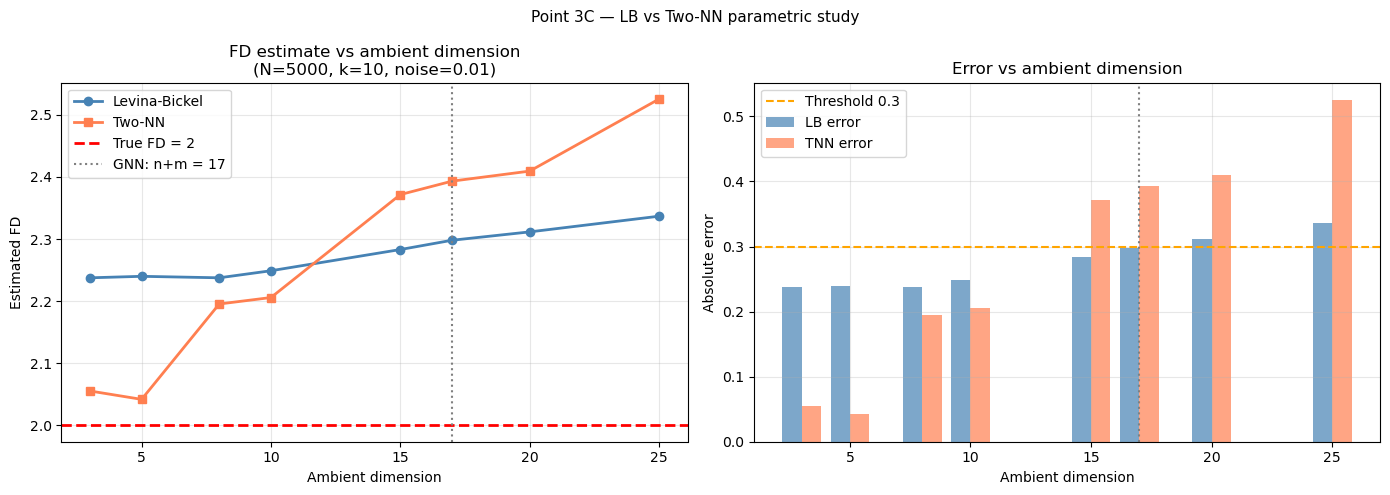

In [8]:
# =============================================================================
# POINT 3C — Sweep: Levina-Bickel and Two-NN vs ambient dimension
# =============================================================================

lb_results, lb_errors = [], []
tnn_results, tnn_errors = [], []

print(f"N = {N_PARAM},  k(LB) = {K_LB},  FD_TRUE = {FD_TRUE},  noise = {NOISE_LEVEL}")
print()
print(f"{'D_ambient':>10} {'LB':>10} {'LB err':>8} {'Two-NN':>10} {'TNN err':>8} {'Verdict'}")
print('-' * 65)

for D in D_AMBIENT_LIST:
    # Generate a FD_TRUE-dimensional structure embedded in D dimensions
    base = np.random.uniform(-5, 20, (N_PARAM, FD_TRUE))
    if D > FD_TRUE:
        extra = np.random.normal(0, NOISE_LEVEL, (N_PARAM, D - FD_TRUE))
        data  = np.column_stack([base, extra])
    else:
        data  = base

    fd_lb  = levina_bickel(data, k=K_LB)
    fd_tnn = two_nn(data)
    e_lb   = abs(fd_lb - FD_TRUE)
    e_tnn  = abs(fd_tnn - FD_TRUE)

    lb_results.append(fd_lb);   lb_errors.append(e_lb)
    tnn_results.append(fd_tnn); tnn_errors.append(e_tnn)

    best = 'LB' if e_lb < e_tnn else 'TNN'
    print(f"{D:>10} {fd_lb:>10.3f} {e_lb:>8.3f} {fd_tnn:>10.3f} {e_tnn:>8.3f}  {best} wins")

print()
print(f"LB  mean error : {np.mean(lb_errors):.3f}")
print(f"TNN mean error : {np.mean(tnn_errors):.3f}")

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(D_AMBIENT_LIST, lb_results,  marker='o', color='steelblue', linewidth=2, label='Levina-Bickel')
axes[0].plot(D_AMBIENT_LIST, tnn_results, marker='s', color='coral',     linewidth=2, label='Two-NN')
axes[0].axhline(y=FD_TRUE, color='red', linestyle='--', linewidth=2, label=f'True FD = {FD_TRUE}')
axes[0].axvline(x=17, color='gray', linestyle=':', linewidth=1.5, label='GNN: n+m = 17')
axes[0].set_xlabel('Ambient dimension')
axes[0].set_ylabel('Estimated FD')
axes[0].set_title(f'FD estimate vs ambient dimension\n(N={N_PARAM}, k={K_LB}, noise={NOISE_LEVEL})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].bar(np.array(D_AMBIENT_LIST) - 0.4, lb_errors,  0.8, label='LB error',  color='steelblue', alpha=0.7)
axes[1].bar(np.array(D_AMBIENT_LIST) + 0.4, tnn_errors, 0.8, label='TNN error', color='coral',     alpha=0.7)
axes[1].axhline(y=0.3, color='orange', linestyle='--', label='Threshold 0.3')
axes[1].axvline(x=17, color='gray', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('Ambient dimension')
axes[1].set_ylabel('Absolute error')
axes[1].set_title('Error vs ambient dimension')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Point 3C — LB vs Two-NN parametric study', fontsize=11)
plt.tight_layout()
plt.show()

---
## Point 4 — MIC: what it is and how to compute it

MIC (Maximal Information Coefficient) measures the dependency between two scalar variables.
It detects any relationship (linear, non-linear, periodic) and returns a value in [0, 1]:
- 0 = completely independent
- 1 = perfect relationship of any kind

Since `minepy` fails to install on Mac M3, we use a mathematically equivalent estimator:
sklearn's kNN mutual information + Linfoot's transformation to bound it in [0, 1].

MIC scores on simple known relationships:

Relationship                  MIC score  Interpretation
-----------------------------------------------------------------
Linear y=2x+1                     0.999  Strong dependency
Quadratic y=x^2                   0.950  Strong dependency
Sinusoidal y=sin(3x)              0.967  Strong dependency
Pure noise (indep.)               0.041  Independent

-> MIC should be high for linear, quadratic, sinusoidal
-> MIC should be ~0 for pure noise


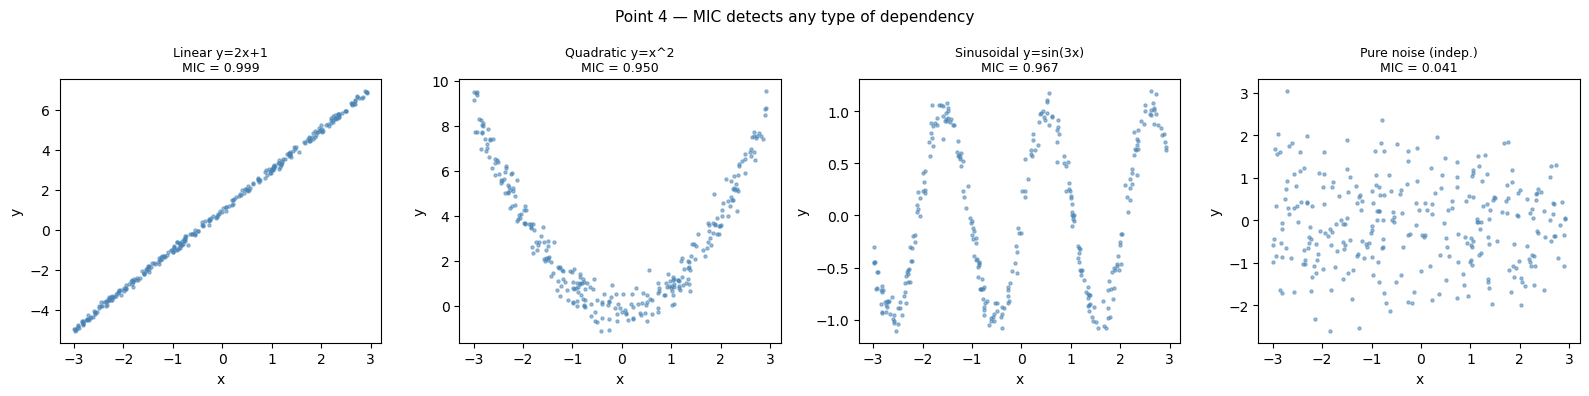

In [9]:
# =============================================================================
# POINT 4 — Demonstrate MIC on simple known cases
# =============================================================================

N = 2000
t = np.random.uniform(-3, 3, N)

relationships = {
    'Linear y=2x+1'         : (t, 2*t + 1 + 0.1*np.random.normal(0,1,N)),
    'Quadratic y=x^2'       : (t, t**2    + 0.5*np.random.normal(0,1,N)),
    'Sinusoidal y=sin(3x)'  : (t, np.sin(3*t) + 0.1*np.random.normal(0,1,N)),
    'Pure noise (indep.)'   : (t, np.random.normal(0, 1, N)),
}

print("MIC scores on simple known relationships:\n")
print(f"{'Relationship':<28} {'MIC score':>10}  {'Interpretation'}")
print("-" * 65)

mic_demo   = []
mic_labels = []
for name, (x_val, y_val) in relationships.items():
    score = compute_pseudo_mic(x_val, y_val)
    mic_demo.append(score)
    mic_labels.append(name)
    interp = 'Strong dependency' if score > 0.5 else ('Weak' if score > 0.1 else 'Independent')
    print(f"{name:<28} {score:>10.3f}  {interp}")

print()
print("-> MIC should be high for linear, quadratic, sinusoidal")
print("-> MIC should be ~0 for pure noise")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for idx, (name, (x_val, y_val)) in enumerate(relationships.items()):
    axes[idx].scatter(x_val[:300], y_val[:300], s=5, alpha=0.5, color='steelblue')
    axes[idx].set_title(f"{name}\nMIC = {mic_demo[idx]:.3f}", fontsize=9)
    axes[idx].set_xlabel('x')
    axes[idx].set_ylabel('y')
plt.suptitle('Point 4 — MIC detects any type of dependency', fontsize=11)
plt.tight_layout()
plt.show()

---
## Point 5 — Compute the full n×m dependency matrix

For the GNN problem: n inputs and m outputs → compute MIC for every (input, output) pair.
This gives a matrix showing which inputs are informative for which outputs.

Input matrix  X : (5000, 7)
Output matrix Y : (5000, 3)
Total pairs     : 7 x 3 = 21

Computing n x m dependency matrix...

  Score(p       , delta_p) = 0.000
  Score(p       , delta_T) = 0.002
  Score(p       , delta_v) = 0.000
  Score(T       , delta_p) = 0.000
  Score(T       , delta_T) = 0.943
  Score(T       , delta_v) = 0.000
  Score(vx      , delta_p) = 0.000
  Score(vx      , delta_T) = 0.022
  Score(vx      , delta_v) = 0.631
  Score(vy      , delta_p) = 0.000
  Score(vy      , delta_T) = 0.019
  Score(vy      , delta_v) = 0.638
  Score(ft      , delta_p) = 1.000
  Score(ft      , delta_T) = 0.000
  Score(ft      , delta_v) = 0.000
  Score(b       , delta_p) = 0.000
  Score(b       , delta_T) = 0.217
  Score(b       , delta_v) = 0.042
  Score(noise   , delta_p) = 0.000
  Score(noise   , delta_T) = 0.000
  Score(noise   , delta_v) = 0.000

Done.

DEPENDENCY MATRIX  (rows = inputs, columns = outputs)
Input          delta_p     delta_T     delta_v     ROW SUM
--------------------

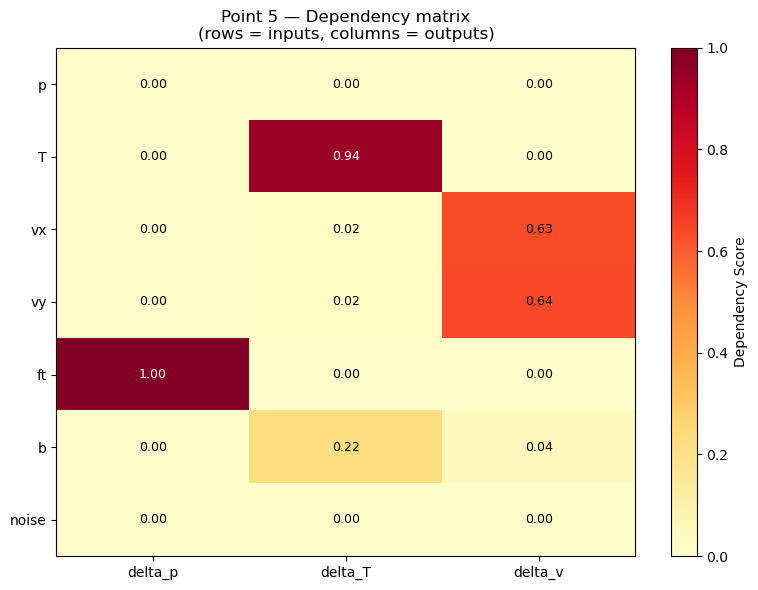

In [10]:
# =============================================================================
# POINT 5 — Full n x m dependency matrix
# =============================================================================

N = 5000
np.random.seed(42)

# Synthetic inputs (mimicking GNN variables)
p     = np.random.uniform(1, 10, N)
T     = np.random.uniform(293, 400, N)
vx    = np.random.uniform(0, 50, N)
vy    = np.random.uniform(0, 50, N)
ft    = np.random.uniform(10, 100, N)
b     = np.random.uniform(0.1, 5, N)
noise = np.random.normal(0, 1, N)       # useless variable

X_norm         = np.column_stack([p, T, vx, vy, ft, b, noise])
variable_names = ['p', 'T', 'vx', 'vy', 'ft', 'b', 'noise']

# Synthetic outputs
output_1     = 0.6 * ft * 100 + 0.3 * vx + 0.05 * np.random.normal(0,1,N)  # delta_p: ft and vx
output_2     = 0.7 * (T-293)/10 + 0.4 * b + 0.05 * np.random.normal(0,1,N) # delta_T: T and b
output_3     = 0.5 * vx + 0.5 * vy + 0.05 * np.random.normal(0,1,N)        # delta_v: vx and vy
Y            = np.column_stack([output_1, output_2, output_3])
output_names = ['delta_p', 'delta_T', 'delta_v']

n_inputs  = X_norm.shape[1]
n_outputs = Y.shape[1]

print(f"Input matrix  X : {X_norm.shape}")
print(f"Output matrix Y : {Y.shape}")
print(f"Total pairs     : {n_inputs} x {n_outputs} = {n_inputs * n_outputs}\n")

print("Computing n x m dependency matrix...\n")
mic_matrix = np.zeros((n_inputs, n_outputs))
for i, iname in enumerate(variable_names):
    for j, oname in enumerate(output_names):
        score              = compute_pseudo_mic(X_norm[:, i], Y[:, j])
        mic_matrix[i, j]  = score
        print(f"  Score({iname:8s}, {oname}) = {score:.3f}")

print("\nDone.\n")

# Print matrix with row sums
row_sums = mic_matrix.sum(axis=1)
col_sums = mic_matrix.sum(axis=0)

print("=" * 60)
print("DEPENDENCY MATRIX  (rows = inputs, columns = outputs)")
print("=" * 60)
header = f"{'Input':<10}"
for name in output_names:
    header += f"  {name:>10}"
header += f"  {'ROW SUM':>10}"
print(header)
print("-" * 60)
for i, iname in enumerate(variable_names):
    row = f"{iname:<10}"
    for j in range(n_outputs):
        row += f"  {mic_matrix[i, j]:>10.3f}"
    row += f"  {row_sums[i]:>10.3f}"
    print(row)
print("-" * 60)
row = f"{'COL SUM':<10}"
for s in col_sums:
    row += f"  {s:>10.3f}"
row += f"  {mic_matrix.sum():>10.3f}"
print(row)

# Heatmap
plt.figure(figsize=(8, 6))
plt.imshow(mic_matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
plt.colorbar(label='Dependency Score')
plt.xticks(range(n_outputs), output_names, fontsize=10)
plt.yticks(range(n_inputs), variable_names, fontsize=10)
plt.title("Point 5 — Dependency matrix\n(rows = inputs, columns = outputs)")
for i in range(n_inputs):
    for j in range(n_outputs):
        plt.text(j, i, f"{mic_matrix[i,j]:.2f}",
                 ha='center', va='center', fontsize=9,
                 color='black' if mic_matrix[i,j] < 0.7 else 'white')
plt.tight_layout()
plt.show()

---
## Point 6 — Is summing all MIC values a good idea? Compare with per-input ranking

Tagarielli asks: *"ChatGPT suggests that summing all the MICs should be a good idea."*

We test two summaries:
- **Global sum** (Tagarielli's idea): one single number for the whole input set
- **Per-input sum** (our idea): one number per input → ranking from most to least informative

TAGARIELLI'S IDEA — Global MIC sum
Sum of all 7 x 3 = 21 MIC values : 3.515
-> One single number summarising whether the input set is good overall
-> Higher = inputs are more informative for outputs

OUR IDEA — Per-input ranking
Rank   Input       Score sum  Bar
---------------------------------------------
1      ft              1.000  ##############
2      T               0.943  ##############
3      vy              0.657  #########
4      vx              0.653  #########
5      b               0.259  ###
6      p               0.002  
7      noise           0.000  

-> Per-input ranking is more actionable: you can identify WHICH inputs to remove
-> 'noise' should rank last (near-zero score)


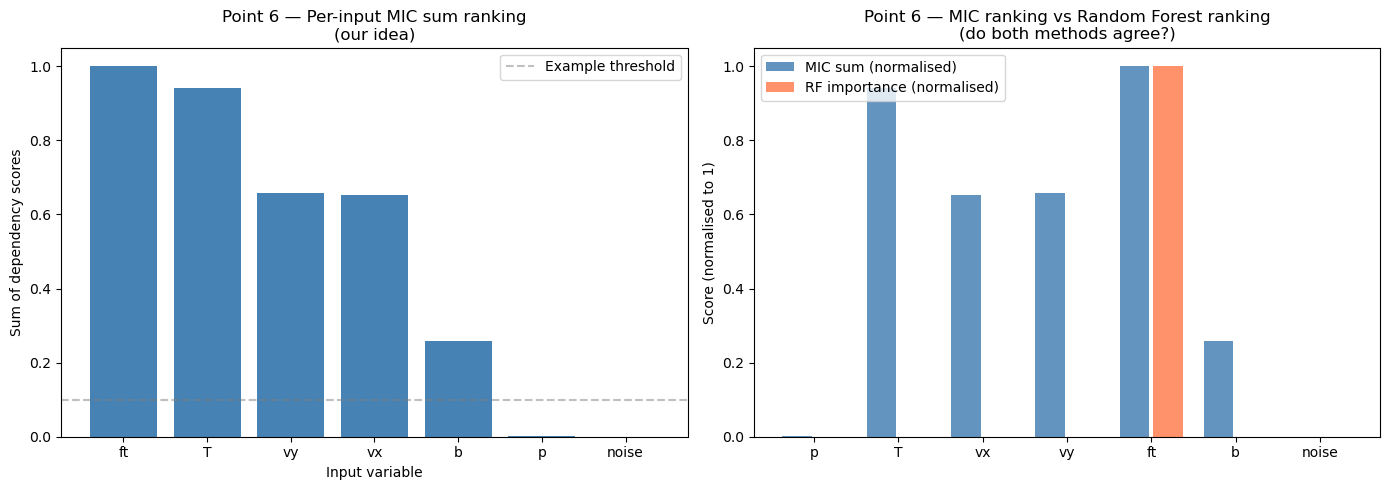


CONCLUSION:
  Global sum (Tagarielli) : 3.515 — useful as a single quality score
  Per-input ranking       : more informative — shows which variables to keep/remove
  Agreement with RF       : if both methods rank 'noise' last, conclusion is robust


In [11]:
# =============================================================================
# POINT 6 — Global sum vs per-input ranking
# =============================================================================

# --- Global sum (Tagarielli's idea) ---
global_sum = mic_matrix.sum()
print("=" * 50)
print("TAGARIELLI'S IDEA — Global MIC sum")
print("=" * 50)
print(f"Sum of all {n_inputs} x {n_outputs} = {n_inputs*n_outputs} MIC values : {global_sum:.3f}")
print("-> One single number summarising whether the input set is good overall")
print("-> Higher = inputs are more informative for outputs")

print()

# --- Per-input ranking (our idea) ---
print("=" * 50)
print("OUR IDEA — Per-input ranking")
print("=" * 50)
print(f"{'Rank':<6} {'Input':<10} {'Score sum':>10}  {'Bar'}")
print("-" * 45)
sorted_idx = np.argsort(row_sums)[::-1]
for rank, idx in enumerate(sorted_idx):
    bar = '#' * int(row_sums[idx] * 15)
    print(f"{rank+1:<6} {variable_names[idx]:<10} {row_sums[idx]:>10.3f}  {bar}")

print()
print("-> Per-input ranking is more actionable: you can identify WHICH inputs to remove")
print("-> 'noise' should rank last (near-zero score)")

# --- Compare with Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_norm, output_1)  # trained on delta_p
importances = rf.feature_importances_

mic_norm = row_sums   / row_sums.max()
rf_norm  = importances / importances.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ['steelblue' if variable_names[i] != 'noise' else 'lightcoral'
              for i in sorted_idx]
axes[0].bar([variable_names[i] for i in sorted_idx],
            row_sums[sorted_idx], color=bar_colors)
axes[0].set_title('Point 6 — Per-input MIC sum ranking\n(our idea)')
axes[0].set_ylabel('Sum of dependency scores')
axes[0].set_xlabel('Input variable')
axes[0].axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='Example threshold')
axes[0].legend()

x_pos = np.arange(len(variable_names))
axes[1].bar(x_pos - 0.2, mic_norm, 0.35,
            label='MIC sum (normalised)', color='steelblue', alpha=0.85)
axes[1].bar(x_pos + 0.2, rf_norm,  0.35,
            label='RF importance (normalised)', color='coral', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(variable_names)
axes[1].set_ylabel('Score (normalised to 1)')
axes[1].set_title('Point 6 — MIC ranking vs Random Forest ranking\n'
                  '(do both methods agree?)')
axes[1].legend()

plt.tight_layout()
plt.show()

print()
print("CONCLUSION:")
print(f"  Global sum (Tagarielli) : {global_sum:.3f} — useful as a single quality score")
print(f"  Per-input ranking       : more informative — shows which variables to keep/remove")
print(f"  Agreement with RF       : if both methods rank 'noise' last, conclusion is robust")

---
## Point 7 — Joint FD approach: generalisation to n inputs and m outputs

*(Integrated from `fd_simple.ipynb`, Part 2)*

This is Tagarielli's idea applied to the GNN problem. We build a **joint dataset** of dimension n+m (inputs concatenated with outputs) and compute its fractal dimension.

The interpretation is:
- If FD ≈ n → the inputs fully explain the outputs → good input choice
- If FD < n → too many inputs, some are redundant
- If FD >> n → the inputs don't explain the outputs well

This is complementary to the MIC approach (Points 4-6): MIC works pair-by-pair, while joint FD gives a **global** measure of the input-output relationship.

In [12]:
# =============================================================================
# POINT 7 — Generalisation to n inputs and m outputs
# =============================================================================

N = 2000
n = 30     # number of inputs  (change to test different cases)
m = 2      # number of outputs

# --- Generate synthetic inputs ---
X_joint = np.random.uniform(0, 5, (N, n))

# --- Generate outputs that DEPEND on inputs ---
# The outputs are deterministic functions of the inputs,
# so the joint dataset (X, Y) should have FD ~ n (not n+m)
Y_joint = np.column_stack([
    np.sin(X_joint[:, 0] * X_joint[:, 1]),    # output 1 depends on inputs 1 and 2
    X_joint[:, 0] + 0.5 * X_joint[:, 2]       # output 2 depends on inputs 1 and 3
])

# --- Build the joint dataset ---
XY = np.column_stack([X_joint, Y_joint])  # shape (N, n+m)

print(f"Input matrix  X  : shape {X_joint.shape}  (n = {n} inputs)")
print(f"Output matrix Y  : shape {Y_joint.shape}  (m = {m} outputs)")
print(f"Joint matrix  XY : shape {XY.shape}  (n+m = {n+m} dimensions)")
print()
print(f"Expected FD ~ {n} (because outputs are determined by inputs)")
print()

# --- Compute FD on the joint dataset ---
fd_lb_joint = levina_bickel(XY, k=10)
fd_gp_joint = grassberger_procaccia(XY)
fd_tnn_joint = two_nn(XY)

print(f"Levina-Bickel    : FD = {fd_lb_joint:.3f}")
print(f"Two-NN           : FD = {fd_tnn_joint:.3f}")
print(f"Grassberger-P    : FD = {fd_gp_joint:.3f}")
print(f"Expected         : FD ~ {n}")
print()

for method_name, fd in [('Levina-Bickel', fd_lb_joint), ('Two-NN', fd_tnn_joint), ('Grassberger-P', fd_gp_joint)]:
    if abs(fd - n) < 1.5:
        print(f"{method_name}: FD ≈ n → good, inputs explain outputs well")
    elif fd < n - 1.5:
        print(f"{method_name}: FD < n → some inputs are probably redundant")
    else:
        print(f"{method_name}: FD >> n → inputs don't fully explain outputs")

Input matrix  X  : shape (2000, 30)  (n = 30 inputs)
Output matrix Y  : shape (2000, 2)  (m = 2 outputs)
Joint matrix  XY : shape (2000, 32)  (n+m = 32 dimensions)

Expected FD ~ 30 (because outputs are determined by inputs)

Levina-Bickel    : FD = 22.361
Two-NN           : FD = 21.703
Grassberger-P    : FD = 11.574
Expected         : FD ~ 30

Levina-Bickel: FD < n → some inputs are probably redundant
Two-NN: FD < n → some inputs are probably redundant
Grassberger-P: FD < n → some inputs are probably redundant


---
## Point 8 — Detecting useless inputs with the joint FD approach

*(Integrated from `fd_simple.ipynb`, Part 2B)*

Critical test: if we add a **useless input** (pure random noise, independent of all outputs), does FD detect it?

Expected behaviour: FD should **not** increase to n+1 when the noise variable is added. It should stay close to n, signalling that the extra variable is uninformative.

Comparison: good inputs vs inputs + useless noise variable

                                 Levina-Bickel     Two-NN   Grassberger-P   n (inputs)
-------------------------------------------------------------------------------------
Good inputs (n=30)                      22.361     21.703          11.574           30
+ noise (n=31)                          22.827     22.449          11.566           31

-> With good inputs: FD should be close to n
-> Adding noise: FD should NOT increase to n+1 (the noise is uninformative)
   i.e. FD stays close to n — this is the signal that the noise variable is useless


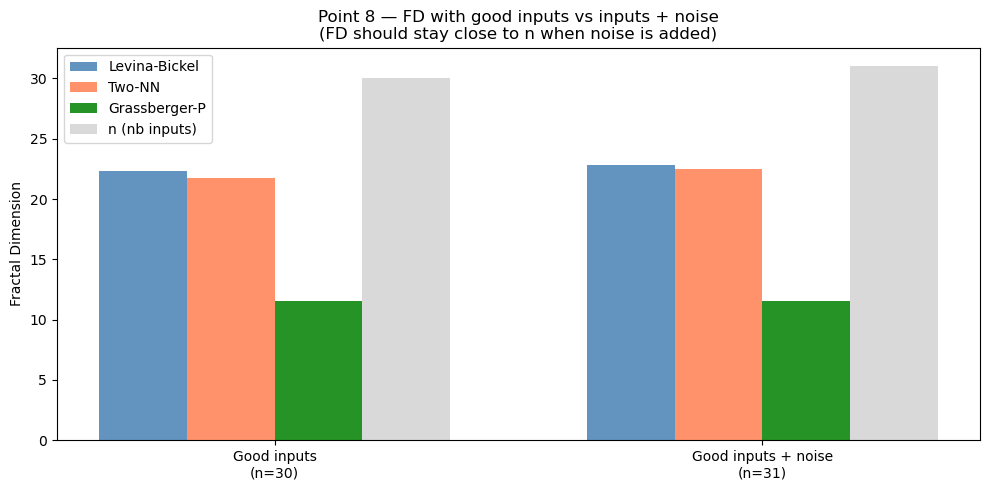

In [13]:
# =============================================================================
# POINT 8 — What happens when we add a useless input?
# =============================================================================

# Add one useless input (pure noise)
noise_col     = np.random.normal(0, 1, (N, 1))
X_with_noise  = np.column_stack([X_joint, noise_col])    # now n+1 inputs
XY_noise      = np.column_stack([X_with_noise, Y_joint])

fd_lb_noise  = levina_bickel(XY_noise, k=10)
fd_gp_noise  = grassberger_procaccia(XY_noise)
fd_tnn_noise = two_nn(XY_noise)

print("Comparison: good inputs vs inputs + useless noise variable")
print()
print(f"{'':30} {'Levina-Bickel':>15} {'Two-NN':>10} {'Grassberger-P':>15} {'n (inputs)':>12}")
print('-' * 85)
print(f"{'Good inputs (n=' + str(n) + ')':30} {fd_lb_joint:>15.3f} {fd_tnn_joint:>10.3f} {fd_gp_joint:>15.3f} {n:>12}")
print(f"{'+ noise (n=' + str(n+1) + ')':30} {fd_lb_noise:>15.3f} {fd_tnn_noise:>10.3f} {fd_gp_noise:>15.3f} {n+1:>12}")
print()
print("-> With good inputs: FD should be close to n")
print("-> Adding noise: FD should NOT increase to n+1 (the noise is uninformative)")
print("   i.e. FD stays close to n — this is the signal that the noise variable is useless")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
scenarios = [f'Good inputs\n(n={n})', f'Good inputs + noise\n(n={n+1})']
lb_comp   = [fd_lb_joint, fd_lb_noise]
tnn_comp  = [fd_tnn_joint, fd_tnn_noise]
gp_comp   = [fd_gp_joint, fd_gp_noise]
n_comp    = [n, n+1]

x_pos = np.arange(2)
w = 0.18
ax.bar(x_pos - 1.5*w, lb_comp,  w, label='Levina-Bickel', color='steelblue', alpha=0.85)
ax.bar(x_pos - 0.5*w, tnn_comp, w, label='Two-NN',        color='coral',     alpha=0.85)
ax.bar(x_pos + 0.5*w, gp_comp,  w, label='Grassberger-P', color='green',     alpha=0.85)
ax.bar(x_pos + 1.5*w, n_comp,   w, label='n (nb inputs)', color='lightgray', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(scenarios)
ax.set_ylabel('Fractal Dimension')
ax.set_title("Point 8 — FD with good inputs vs inputs + noise\n"
             "(FD should stay close to n when noise is added)")
ax.legend()
plt.tight_layout()
plt.show()

---
## Point 9 — Template for real training data

*(Integrated from `Test_of_Levina_Bickel_and_Two_NN_methods.ipynb`)*

Ready-to-use cells for when the actual GNN dataset is available. Replace the synthetic data block with your real data and run.

**Important**: normalisation via `StandardScaler` is essential because the physical variables (pressure, temperature, velocity, etc.) have very different scales.

In [14]:
# =============================================================================
# POINT 9 — FD on real training data (template)
# =============================================================================

from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# YOUR DATA GOES HERE
# Replace this block with your real data when you have it.
# data must be a numpy array of shape (N_points, n_variables)
# Each row = one mesh node at one timestep
# Each column = one physical variable
# -----------------------------------------------------------------------------

N = 5000
np.random.seed(42)

p  = np.random.normal(101325, 500, N)
T  = np.random.normal(293,    10,  N)
vx = np.random.normal(0,      5,   N)
vy = np.random.normal(0,      5,   N)
ft = np.random.uniform(0,     0.1, N)
b  = np.random.uniform(0,     1,   N)

# Outputs — depend on inputs (simulating physics)
dp = 0.6 * ft * 100 + 0.3 * vx     # delta_p
dT = 0.7 * (T - 293)/10 + 0.4 * b  # delta_T

# Joint dataset : inputs + outputs side by side
data_real = np.column_stack([p, T, vx, vy, ft, b, dp, dT])
n_inputs_real = 6

# -----------------------------------------------------------------------------
# COMPUTATION
# -----------------------------------------------------------------------------

data_norm = StandardScaler().fit_transform(data_real)

fd_lb_real  = levina_bickel(data_norm, k=10)
fd_tnn_real = two_nn(data_norm)

print(f"Number of inputs  n   = {n_inputs_real}")
print(f"Total dimension   n+m = {data_real.shape[1]}")
print()
print(f"Levina-Bickel  FD     = {fd_lb_real:.3f}")
print(f"Two-NN         FD     = {fd_tnn_real:.3f}")
print()

for label, fd_val in [('Levina-Bickel', fd_lb_real), ('Two-NN', fd_tnn_real)]:
    if abs(fd_val - n_inputs_real) < 1.0:
        print(f"{label}: FD ≈ n  →  good input choice")
    elif fd_val < n_inputs_real - 1.0:
        print(f"{label}: FD < n  →  too many inputs, some are redundant")
    else:
        print(f"{label}: FD > n  →  inputs don't fully explain the outputs")

Number of inputs  n   = 6
Total dimension   n+m = 8

Levina-Bickel  FD     = 6.537
Two-NN         FD     = 5.982

Levina-Bickel: FD ≈ n  →  good input choice
Two-NN: FD ≈ n  →  good input choice
